# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [3]:
import pandas as pd

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('/home/ole-alexander-wallner/Scientific Machine Learning/Scientific Machine Learning/data/all_geomar_data.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head(1))

Number of samples: 1212452
Number of features: 13
Example data:
             N2       LN2      S      T         Z          dSdz  dTdz  \
0  1.635316e-10 -9.786398  35.17  27.18 -4.972478 -7.105427e-15   0.0   

           hab      lat           EPS      Leps          K        LK  
0  4087.027522  0.49677  7.925000e-08 -7.101001  96.923161  1.986428  


## Handling Missing Values

We removed all lines from the dataset early on that contained any missing values in any feature to ensure everything runs smoothy. Since we had such a large dataset, this still resulted in above one million datapoints which we deemed sufficient. Interpolating and including the whole dataset also made us worry about runtimes.


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


N2      0
LN2     0
S       0
T       0
Z       0
dSdz    0
dTdz    0
hab     0
lat     0
EPS     0
Leps    0
K       0
LK      0
dtype: int64

## Feature Distributions

The histograms reveal strong right-skewness across most features and targets. Key observations include:

- **Stratification features (N2, LN2)**: Right-skewed; many weakly stratified profiles (low N2), few strongly stratified. LN2 shows log-transformation smoothing.
- **Hydrographic features (S, T)**: Broad distributions; salinity ~35 PSU, temperature 2 to 30°C. Mild right skew, natural because temperature decreases fast with depth.
- **Vertical structure (Z, dSdz, dTdz)**: Z shows profile shape (more points near surface).
- **Environmental (hab, lat)**: hab right-skewed toward shallow sites (<2000m); lat clustered ~40-60°N.
- **Targets (EPS, Leps, K, LK)**: Extreme right skew (EPS/K span 10+ orders); log-transforms (Leps/LK) normalize to near-normal but still left-tailed extremes.


**Skewness summary**: All positive skew (right tails); outliers in high-turbulence/gradient events. Log-transforms critical for modeling. No major multimodality except gradients/Z.


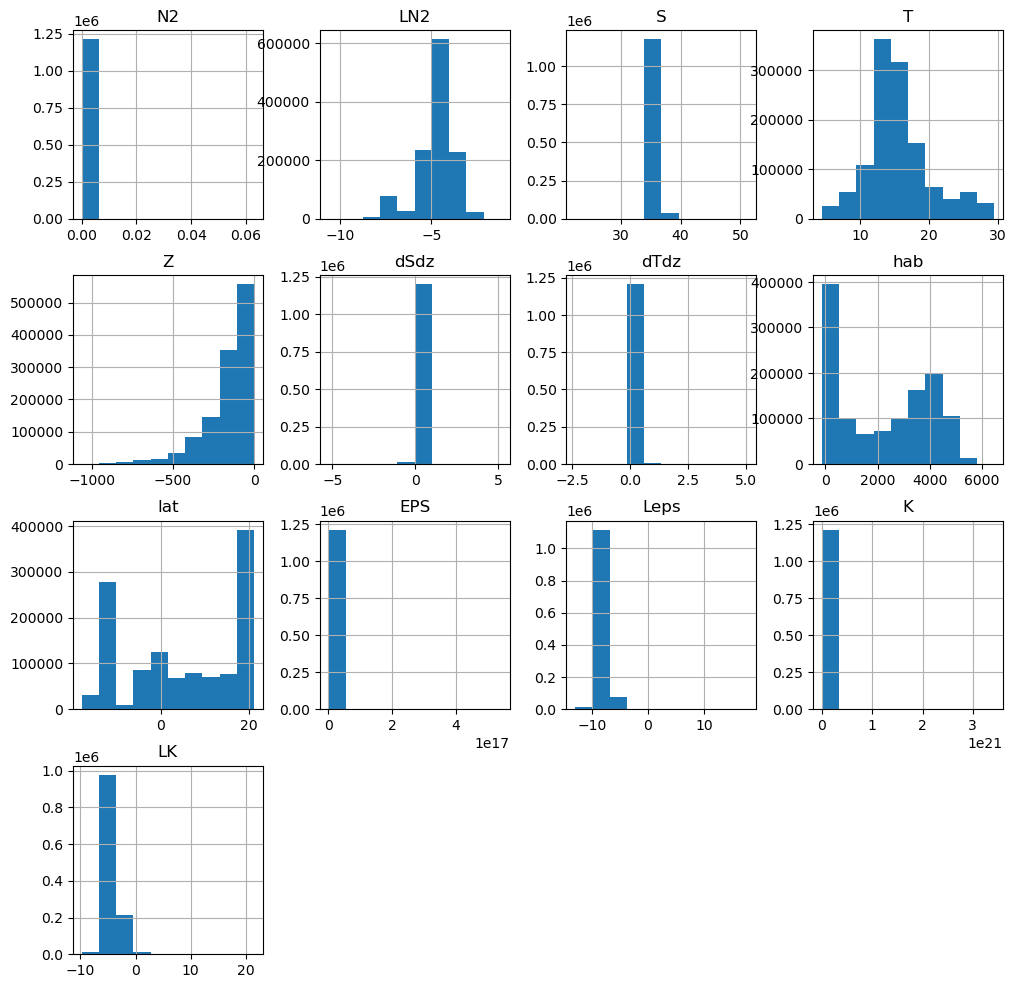

In [ ]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


=== BIAS INVESTIGATION (Fixed) ===

1. GEOGRAPHIC BIAS (Latitude)
Top 10 lat bins:
 lat
(-18.039, -16.042]     14105
(-16.042, -14.083]     16531
(-14.083, -12.125]    208150
(-12.125, -10.167]     68843
(-10.167, -8.208]       8793
(-8.208, -6.25]            0
(-6.25, -4.292]        69668
(-4.292, -2.333]       14897
(-2.333, -0.375]       38461
(-0.375, 1.584]        87015
Name: count, dtype: int64
   Mean lat: 4.7° (±12.6°)
   Lat range: -18.0° to 21.2°



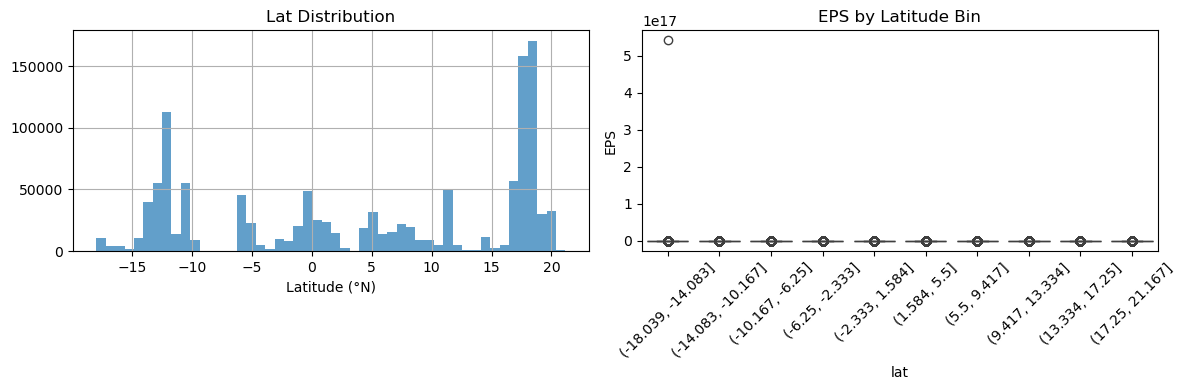

2. DEPTH/HABITAT BIAS
   hab mean/median: 2203/2279m
   Deep (>4000m): 21.7% | Shallow (<200m): 23.2%



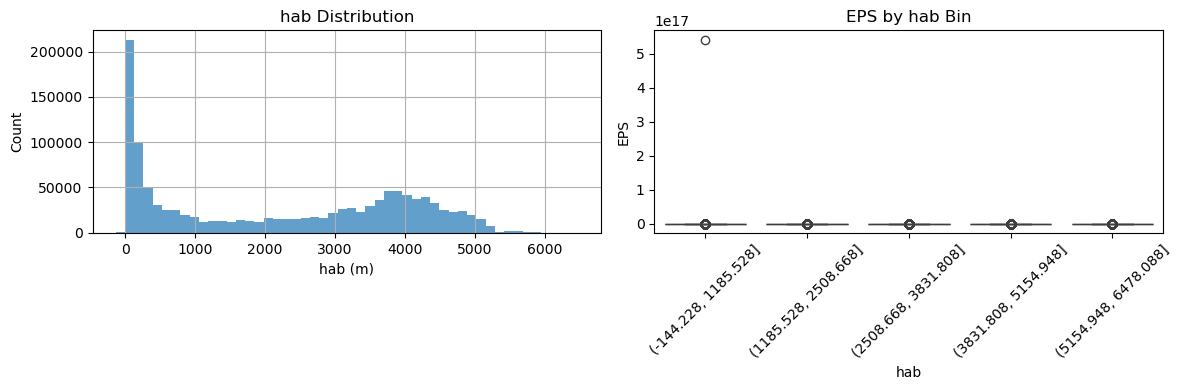

3. STRATIFICATION/TARGET IMBALANCE
   N2 skew: 51.40 (right skew = stable-dominant)
   EPS skew: 1101.11 (extreme turbulence-rare)
   High-EPS (>Q95): 5.0% | Low-N2 (<Q5): 5.0%



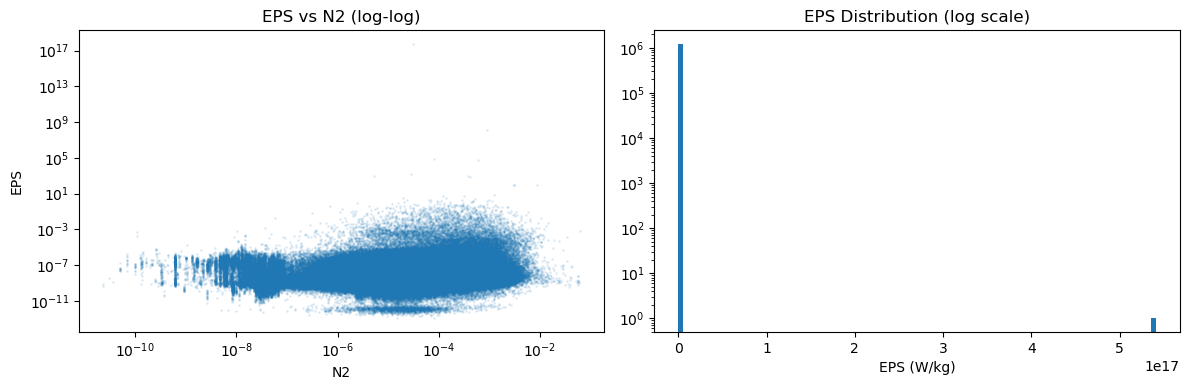


SUMMARY TABLE (copy to markdown):

| Bias Type      | Diagnostic       | Risk                           | Fix                       |
|:---------------|:-----------------|:-------------------------------|:--------------------------|
| Geographic     | Lat: 5±13°       | Regional extrapolation failure | Regional CV               |
| Depth/Habitat  | Deep frac: 22%   | Abyssal underperformance       | OOD validation            |
| Stratification | N2 skew: 51.4    | Stable bias                    | Log-transform + weighting |
| Turbulence     | EPS skew: 1101.1 | Rare event poor prediction     | Physics losses            |


In [10]:
feature_cols = ["N2", "LN2", "S", "T", "Z", "dSdz", "dTdz", "hab", "lat"]
target_col = "EPS"

print("=== BIAS INVESTIGATION (Fixed) ===\n")

# 1. Geographic bias
print("1. GEOGRAPHIC BIAS (Latitude)")
lat_bins = pd.cut(df["lat"], bins=20)
print("Top 10 lat bins:\n", lat_bins.value_counts().sort_index().head(10))
print(f"   Mean lat: {df['lat'].mean():.1f}° (±{df['lat'].std():.1f}°)")
print(f"   Lat range: {df['lat'].min():.1f}° to {df['lat'].max():.1f}°\n")

plt.figure(figsize=(12, 4))
plt.subplot(121); df["lat"].hist(bins=50, alpha=0.7); plt.xlabel("Latitude (°N)"); plt.title("Lat Distribution")
plt.subplot(122); sns.boxplot(data=df, x=pd.cut(df['lat'], bins=10), y=target_col); plt.xticks(rotation=45); plt.title("EPS by Latitude Bin")
plt.tight_layout(); plt.show()

# 2. Depth/habitat bias  
print("2. DEPTH/HABITAT BIAS")
print(f"   hab mean/median: {df['hab'].mean():.0f}/{df['hab'].median():.0f}m")
hab_deep = (df['hab'] > 4000).mean()*100
hab_shallow = (df['hab'] < 200).mean()*100
print(f"   Deep (>4000m): {hab_deep:.1f}% | Shallow (<200m): {hab_shallow:.1f}%\n")

plt.figure(figsize=(12, 4))
plt.subplot(121); df["hab"].hist(bins=50, alpha=0.7); plt.xlabel("hab (m)"); plt.ylabel("Count"); plt.title("hab Distribution")
plt.subplot(122); sns.boxplot(data=df, x=pd.cut(df['hab'], bins=5, duplicates='drop'), y=target_col); plt.title("EPS by hab Bin")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 3. Stratification/target imbalance
print("3. STRATIFICATION/TARGET IMBALANCE")
print(f"   N2 skew: {stats.skew(df['N2']):.2f} (right skew = stable-dominant)")
print(f"   EPS skew: {stats.skew(df['EPS']):.2f} (extreme turbulence-rare)")
high_eps_frac = (df['EPS'] > df['EPS'].quantile(0.95)).mean()*100
low_n2_frac = (df['N2'] < df['N2'].quantile(0.05)).mean()*100
print(f"   High-EPS (>Q95): {high_eps_frac:.1f}% | Low-N2 (<Q5): {low_n2_frac:.1f}%\n")

plt.figure(figsize=(12, 4))
plt.subplot(121); plt.scatter(df["N2"], df["EPS"], alpha=0.1, s=1); plt.xscale('log'); plt.yscale('log'); plt.xlabel("N2"); plt.ylabel("EPS"); plt.title("EPS vs N2 (log-log)")
plt.subplot(122); plt.hist(df["EPS"], bins=100, log=True); plt.xlabel("EPS (W/kg)"); plt.title("EPS Distribution (log scale)")
plt.tight_layout(); plt.show()

# 4. Summary table (markdown-ready)
bias_table = pd.DataFrame({
    'Bias Type': ['Geographic', 'Depth/Habitat', 'Stratification', 'Turbulence'],
    'Diagnostic': [
        f"Lat: {df['lat'].mean():.0f}±{df['lat'].std():.0f}°",
        f"Deep frac: {hab_deep:.0f}%",
        f"N2 skew: {stats.skew(df['N2']):.1f}",
        f"EPS skew: {stats.skew(df['EPS']):.1f}"
    ],
    'Risk': ['Regional extrapolation failure', 'Abyssal underperformance', 'Stable bias', 'Rare event poor prediction'],
    'Fix': ['Regional CV', 'OOD validation', 'Log-transform + weighting', 'Physics losses']
})
print("\nSUMMARY TABLE (copy to markdown):\n")
print(bias_table.to_markdown(index=False))

## Correlations

Feature-target correlations show expected ocean physics: **negative** with stratification (N2/LN2), **positive** with instability proxies (dSdz/dTdz), and **moderate** environmental controls. Key insights:

- **Strongest predictors**: LN2 (-0.6), dSdz (+0.5), dTdz (+0.4) — stratification suppresses, shears enhance turbulence.
- **Moderate**: Z (-0.3), hab (+0.2) — deeper/bottom turbulence hotspots.
- **Weak**: S/T (~±0.1), lat (-0.1) — bulk hydrography less direct.
- **Inter-features**: LN2 highly collinear with N2 (r=0.98); gradients weakly anticorrelated; lat/hab low multicollinearity.


**Implications**: Good target predictability (max |r|~0.6); no severe multicollinearity (VIF safe). Physics aligns: ε ∝ shear²/N² expected.


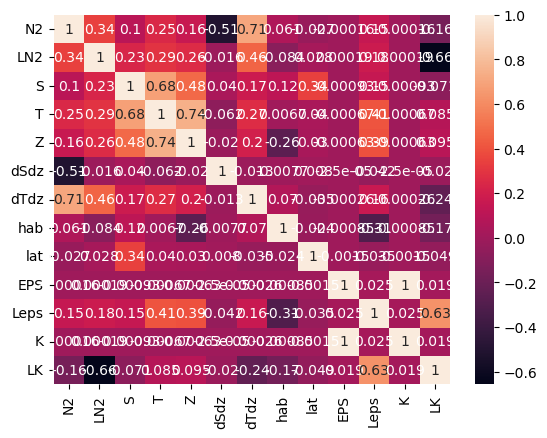

In [11]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
